# Tomography with Chromatix

<a target="_blank" href="NOTE">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
# If in Colab, install Chromatix. Don't forget to select a GPU!
!pip install --upgrade pip
!pip install git+https://github.com/chromatix-team/chromatix.git
# in order to plot 3D volumes, we need to install napari
!pip install "napari[all]"

This example covers the fundamentals of Tomography and how it can be simulated using Chromatix. Tomography is a computational imaging technique used to reconstruct a three-dimensional image of the internal structures of an object from a series of two-dimensional projections taken at different angles.

## Overview of the Tutorial

In this tutorial, we will:
1. **Explain the Fundamentals of Tomography**: We'll briefly cover the basic principles behind tomography, focusing on how projections are obtained and used for reconstruction.
2. **Describe a Computational/Differentiable Approach**: We'll explore a differentiable simulation framework using Chromatix, which allows for gradient-based optimization of the imaging process.
3. **Simulation and Implementation**: We'll simulate the process of rotating a phase or absorptive sample and capturing the intensity measurements through a camera sensor. This process involves the computational equivalent of the Radon transform.

## Radon Transform

The central concept in tomography is the Radon transform, which is used to describe how the internal structure of an object affects the rays passing through it. Mathematically, the Radon transform $R$ of a function $f(x, y)$ representing a 2D object's absorption coefficient is defined as:

$$
R(\theta, s) = \int_{-\infty}^{\infty} f(t \sin \theta + s \cos \theta, s \sin \theta - t \cos \theta) \, dt
$$

where $\theta$ is the angle of projection, and $s$ is the detector position along the projection line.


The inverse radon transform or gradient decent based optimization are often used to reconstruct the image from the resulting sinogram.

## Differentiable Approach

In this tutorial, we simulate the Radon transform by rotating a sample (either phase or absorptive) and capturing the intensity profile with a camera sensor, referred to as the sinogram. We use a computational model that allows for differentiable simulation, enabling the application of gradient descent optimization techniques to reconstruct the sample from its sinogram. By optimizing the parameters of our sample to minimize the difference between the observed and simulated sinograms, we iteratively improve the fidelity of our reconstructed image.

First, import necessary pakages:

In [1]:
import chromatix.functional as cx
import chromatix.utils.fft as cfft
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
# import napari
from jax import Array
from jax.scipy.ndimage import map_coordinates
# import napari
from jax import random
import flax.linen as nn
from flax.training.train_state import TrainState
from optax import adam
import optax
import matplotlib.pyplot as plt
from chromatix import Field
from chromatix.utils import flat_phase
from typing import Any, Tuple
from chex import Array

key = random.PRNGKey(4)

## Creating a 3D sample
We first create a 3D sample volume of desirable size by placing three objects (sphere, cube, and pyramid) in random locations.

In [2]:
def create_volume(shape):
    return np.zeros(shape)

def random_location(shape, object_shape):
    h, w, l = shape
    oh, ow, ol = object_shape
    x = np.random.randint(0, h - oh)
    y = np.random.randint(0, w - ow)
    z = np.random.randint(0, l - ol)
    return x, y, z

def add_sphere(volume, radius):
    h, w, l = volume.shape
    x0, y0, z0 = random_location(volume.shape, (radius*2, radius*2, radius*2))
    for x in range(radius*2):
        for y in range(radius*2):
            for z in range(radius*2):
                if (x-radius)**2 + (y-radius)**2 + (z-radius)**2 <= radius**2:
                    volume[x0 + x, y0 + y, z0 + z] = 1
    return volume

def add_cube(volume, side_length):
    h, w, l = volume.shape
    x0, y0, z0 = random_location(volume.shape, (side_length, side_length, side_length))
    volume[x0:x0+side_length, y0:y0+side_length, z0:z0+side_length] = 2
    return volume

def add_pyramid(volume, base_length):
    h, w, l = volume.shape
    height = base_length // 2
    x0, y0, z0 = random_location(volume.shape, (base_length, base_length, height))
    for i in range(height):
        for x in range(base_length - 2*i):
            for y in range(base_length - 2*i):
                volume[x0 + x + i, y0 + y + i, z0 + i] = 3
    return volume

def plot_volume(volume):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Get the coordinates of the voxels
    x, y, z = np.indices(volume.shape)

    # Extract the coordinates of the non-zero voxels
    x = x[volume > 0]
    y = y[volume > 0]
    z = z[volume > 0]
    values = volume[volume > 0]

    # Plot each object with different colors
    ax.scatter(x, y, z, c=values, cmap='viridis')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    plt.show()

Our 3D smaple is 512x512x512 in resolution. We start by placing the random objects within a 256x256x256 volume and zero pad the smaple afterwards. This is done to prevent the rotation from causing artefacts and cropping at the edges.

In [3]:
shape = (32, 32, 32) # (y, x, z)
height, width, length = shape  # Adjust the size as needed
sample = create_volume(shape)
sample = add_sphere(sample, 15)
sample = add_cube(sample, 15)
sample = add_pyramid(sample, 15)
# zero pad so that objects are in the center
padding = ((shape[0] // 2, ) * 2, (shape[1] // 2, ) * 2, (shape[2] // 2, ) * 2)
sample = jnp.pad(sample, padding, mode='constant', constant_values=0).astype(jnp.float16)
sample -= sample.min()
sample /= sample.max()
# viewer, image_layer = napari.imshow(sample, rgb=False)

In [77]:
sino_sample.max()

Array(19.33, dtype=float16)

## Simulating the optical system
Here we create a function using Chromatix that represents the forward path in our optical system. 

In [4]:
# Optical system parameters
key = jax.random.PRNGKey(42)
# thickness of each sample slice in microns
thickness = 1.0
# length of the field in pixels
size = sample.shape[1:]
# pixel spacing
dx = 0.1154
# wavelength in microns
wavelength = 0.523
# power is 1 per pixel
power = np.prod(size) * dx * dx
# In our tomography system, this is the forward model for one angle only
def pass_through_sample(sample_delay, sample_absorption):
    # Create a plane wave that will pass through our sample
    field = cx.plane_wave(
        shape=size,
        dx=dx,
        spectrum=wavelength,
        spectral_density=1.0,
        power=power,
        kykx = (0, 0)
    )
    # The field is passed through the sample with specified thickness, absorption and phase delay
    field = cx.multislice_thick_sample(
        field,
        sample_absorption,
        sample_delay,
        1.33,
        thickness,
        N_pad=0,
    )
    return field

def simple_sum(sample_delay, sample_absorption):
    field = jnp.sum(sample_absorption.copy(), axis=0).astype(jnp.float16) # summation along the y axis (y, x, z)
    return field


We test this function by placing our sample in the system. First, we assume the sample is an absorptive material. In this case the random sample will be placed as the `sample_absorption` input to the function:

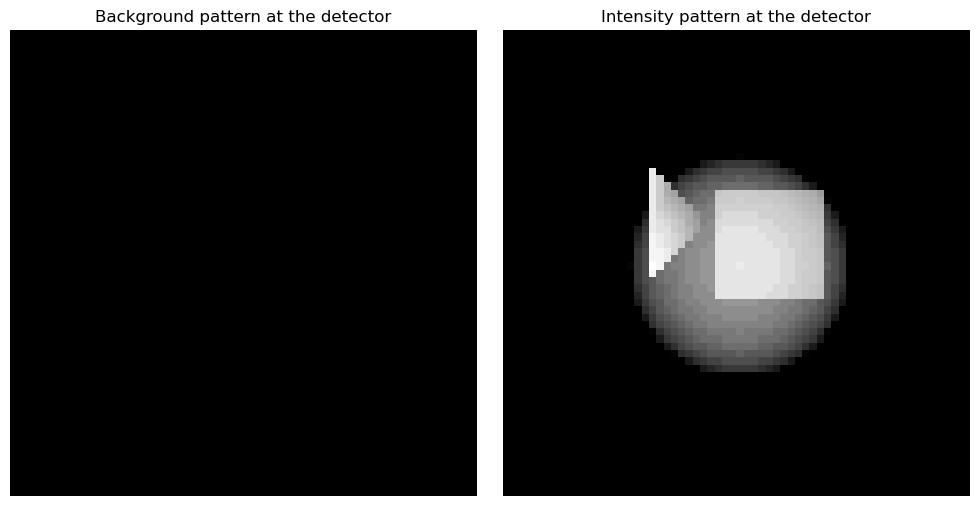

In [5]:
sino_background = simple_sum(sample_delay=np.zeros_like(sample),
                            sample_absorption=np.zeros_like(sample))

sino_sample = simple_sum(sample_delay=np.zeros_like(sample),
                            sample_absorption=sample)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # Adjust the figsize as needed

axs[0].imshow(sino_background, cmap='gray')
axs[0].set_title('Background pattern at the detector')
axs[0].axis('off')
axs[1].imshow(sino_sample, cmap='gray')
axs[1].set_title('Intensity pattern at the detector')
axs[1].axis('off')
plt.tight_layout() 
plt.show()


As mentioned earlier, a critical component of the tomography technique is rotating the sample, in our case, a 3D smaple. Here we define the rotation matrix for each angle using `Ry`, then rotate the sample by calling the function `rotate_volume`:

In [6]:
def Ry(theta: float, dtype=jnp.float16) -> jnp.ndarray:
    """Generates rotation matrix around y.
    Theta in radians."""
    R = jnp.zeros((4, 4), dtype=dtype)
    sin_t = jnp.sin(theta).astype(dtype)
    cos_t = jnp.cos(theta).astype(dtype)

    R = R.at[1, 1].set(1.0)
    R = R.at[3, 3].set(1.0)  # homogeneous
    R = R.at[0, 0].set(cos_t)
    R = R.at[2, 2].set(cos_t)
    R = R.at[0, 2].set(sin_t)
    R = R.at[2, 0].set(-sin_t)

    return R

def volume_homogeneous_grid(volume: Array) -> Array:
    """Given a volume, generates a centred grid of homogeneous coordinates.
    Coordinates are placed along last dimension [z, y, x, 4]"""

    Nz, Ny, Nx = volume.shape
    z = jnp.linspace(-(Nz - 1) / 2, (Nz - 1) / 2, Nz, dtype=volume.dtype)
    y = jnp.linspace(-(Ny - 1) / 2, (Ny - 1) / 2, Ny, dtype=volume.dtype)
    x = jnp.linspace(-(Nx - 1) / 2, (Nx - 1) / 2, Nx, dtype=volume.dtype)
    grid = jnp.stack(jnp.meshgrid(z, y, x, indexing="ij"), axis=-1)
    return jnp.concatenate(
        [grid, jnp.ones((Nz, Ny, Nx, 1), dtype=volume.dtype)], axis=-1
    )

def resample(volume: Array, sample_grid: Array) -> Array:
    """Resample volume on coordinates given by grid.
    Assumes original coordinates were centered, i.e. -N/2 -> N/2"""
    offset = (jnp.array(volume.shape) - 1) / 2
    sample_locations = sample_grid.reshape(-1, 3).T + offset[:, None]
    resampled = map_coordinates(
        volume, list(sample_locations), order=1, mode="constant", cval=0.0
    )
    return resampled.reshape(sample_grid.shape[:3])

def rotate_volume(volume: Array, angle: float) -> Array:
    """Rotates a volume around the y axis (axis 1).
    angle in radians."""
    rotated_grid = volume_homogeneous_grid(volume) @ Ry(angle, volume.dtype).T
    return resample(volume, rotated_grid[..., :3])

The final forward model is the combination of the rotation and propagation through the material. We define a function, `get_sinogram`, that given the sample and a rotation angle will apply the propagation:

In [7]:
def forward_single(sample, angle):
    rot_volume = rotate_volume(sample,
                               angle).astype(jnp.float16)

    detector_pattern = simple_sum(sample_delay = jnp.zeros_like(rot_volume, dtype=jnp.float16),
                                sample_absorption = rot_volume)

    return detector_pattern#.intensity.squeeze()

resolution = 90
max_angle = 2 * np.pi
angles = jnp.linspace(0,
                     max_angle,
                     resolution).astype(jnp.float16)

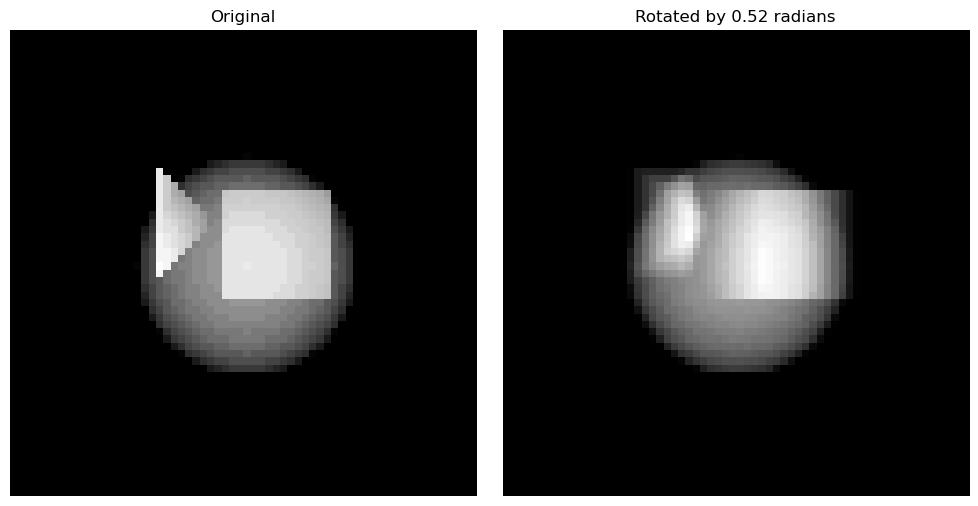

In [8]:
angle = jnp.pi/6
rotated_sample_sino = forward_single(jnp.array(sample.astype(np.float16)), angle)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # Adjust the figsize as needed

axs[0].imshow(sino_sample, cmap='gray')
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(rotated_sample_sino, cmap='gray')
axs[1].set_title(f'Rotated by {angle:.2f} radians')
axs[1].axis('off')
plt.tight_layout() 
plt.show()

### Using `vmap` to calculate all angles
The `get_sinogram` only accepts a single `float` value for angle in radians. However in tomogrpahy we need to measure at a range of angles. For this purpose we vectorize the operation using [`vmap`](https://jax.readthedocs.io/en/latest/automatic-vectorization.html). Calling `jax.vmap` on this function, with the correct inputs, will return another function that can be called on its own. We also compile this function using [`jit`](https://jax.readthedocs.io/en/latest/jit-compilation.html) for optimum performance.

In [9]:
forward_model = jax.jit(jax.vmap(forward_single, in_axes = (None,0)))

We can create a list of angles and get the sinogram of the random sample:

In [10]:
sinogram = forward_model(sample,
                          angles)
print(sinogram.shape)

(90, 64, 64)


We can plot the detecor intensity at different angles:

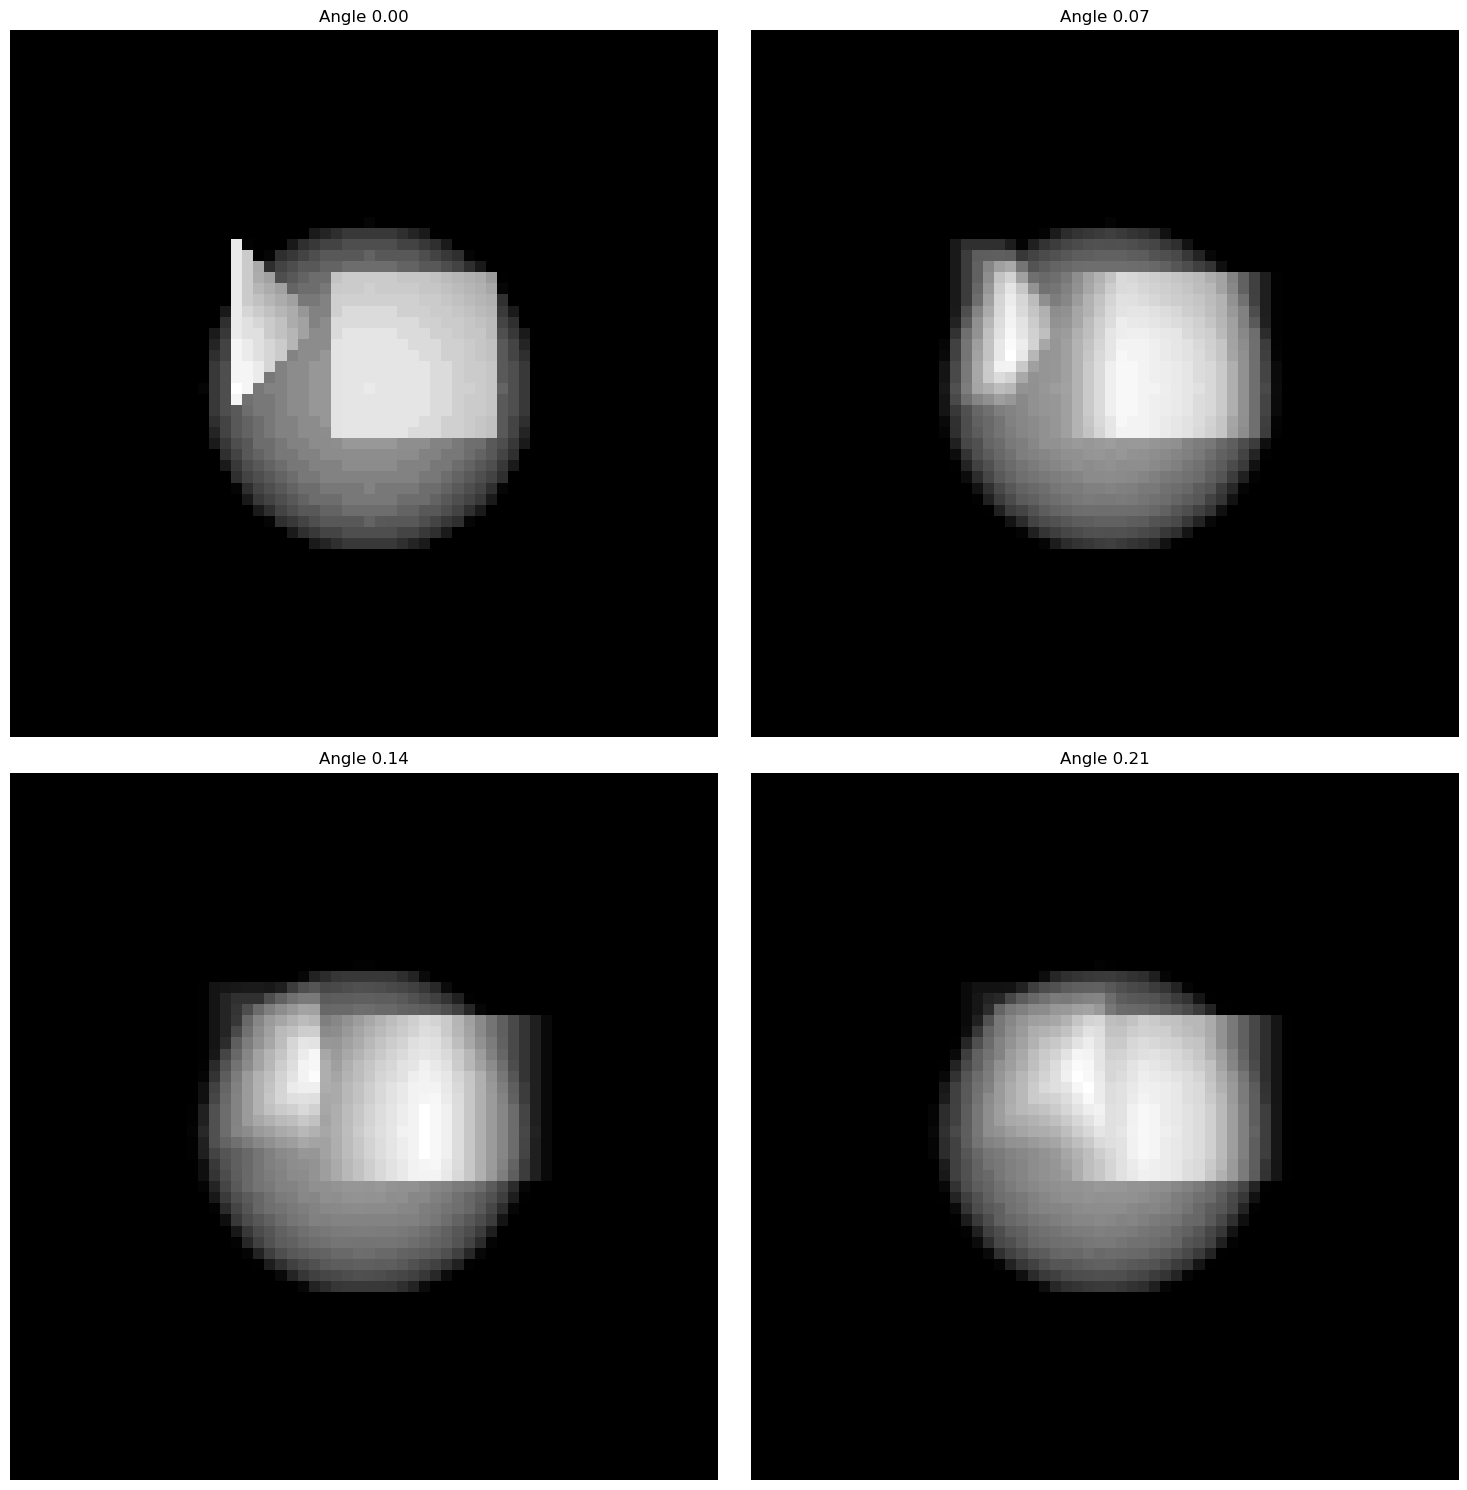

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
# Loop over the grid and plot the selected slices
for i, ax in enumerate(axs.flat):
    # Display the image
    ax.imshow(sinogram[i*5], cmap='gray')
    ax.set_title(f'Angle {angles[i]:.2f}')
    ax.axis('off')  # Turn off axis for cleaner look

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Model definition and optimization
In order to reconstruct the sample, we will define it as a set of parameters. First we start from completely random values. We then use our forward model to simulate the sinogram that would result from that. This will be compared to our sinogram at hand, and their mismatch will be quantified using a loss function and used to optimize the parameters. The easiest way to optimize parameters in Jax is through optax and defining a flax model. Chromatix defines everything in a flax-style module. So here we will define a flax module, using our forward model.

In [12]:
class DifferentiableTomography(nn.Module):
    forward_model: callable
    shape: Tuple[int, int, int]
    angles: Array

    def setup(self):
        # Defining `sample` as a parameter allows us to optimize it
        self.sample = self.param("_sample",
                                 lambda key: jax.random.uniform(key=key,
                                                                shape=self.shape,
                                                                dtype=jnp.float16))

    def __call__(self) -> Field:
        output = self.forward_model(self.sample,
                               self.angles)
        return output

Model is defined. Now we initialize it. The sample will be initialized to all ones. You can modify this if you want in the `param` definition before.

In [13]:
model = DifferentiableTomography(forward_model = forward_model,
                                shape = sample.shape,
                                angles=angles)

variables = model.init(key)

params = variables["params"]
state = {}
del variables # delete for memory

Without any training we can see what the recordings at the detector would look like:

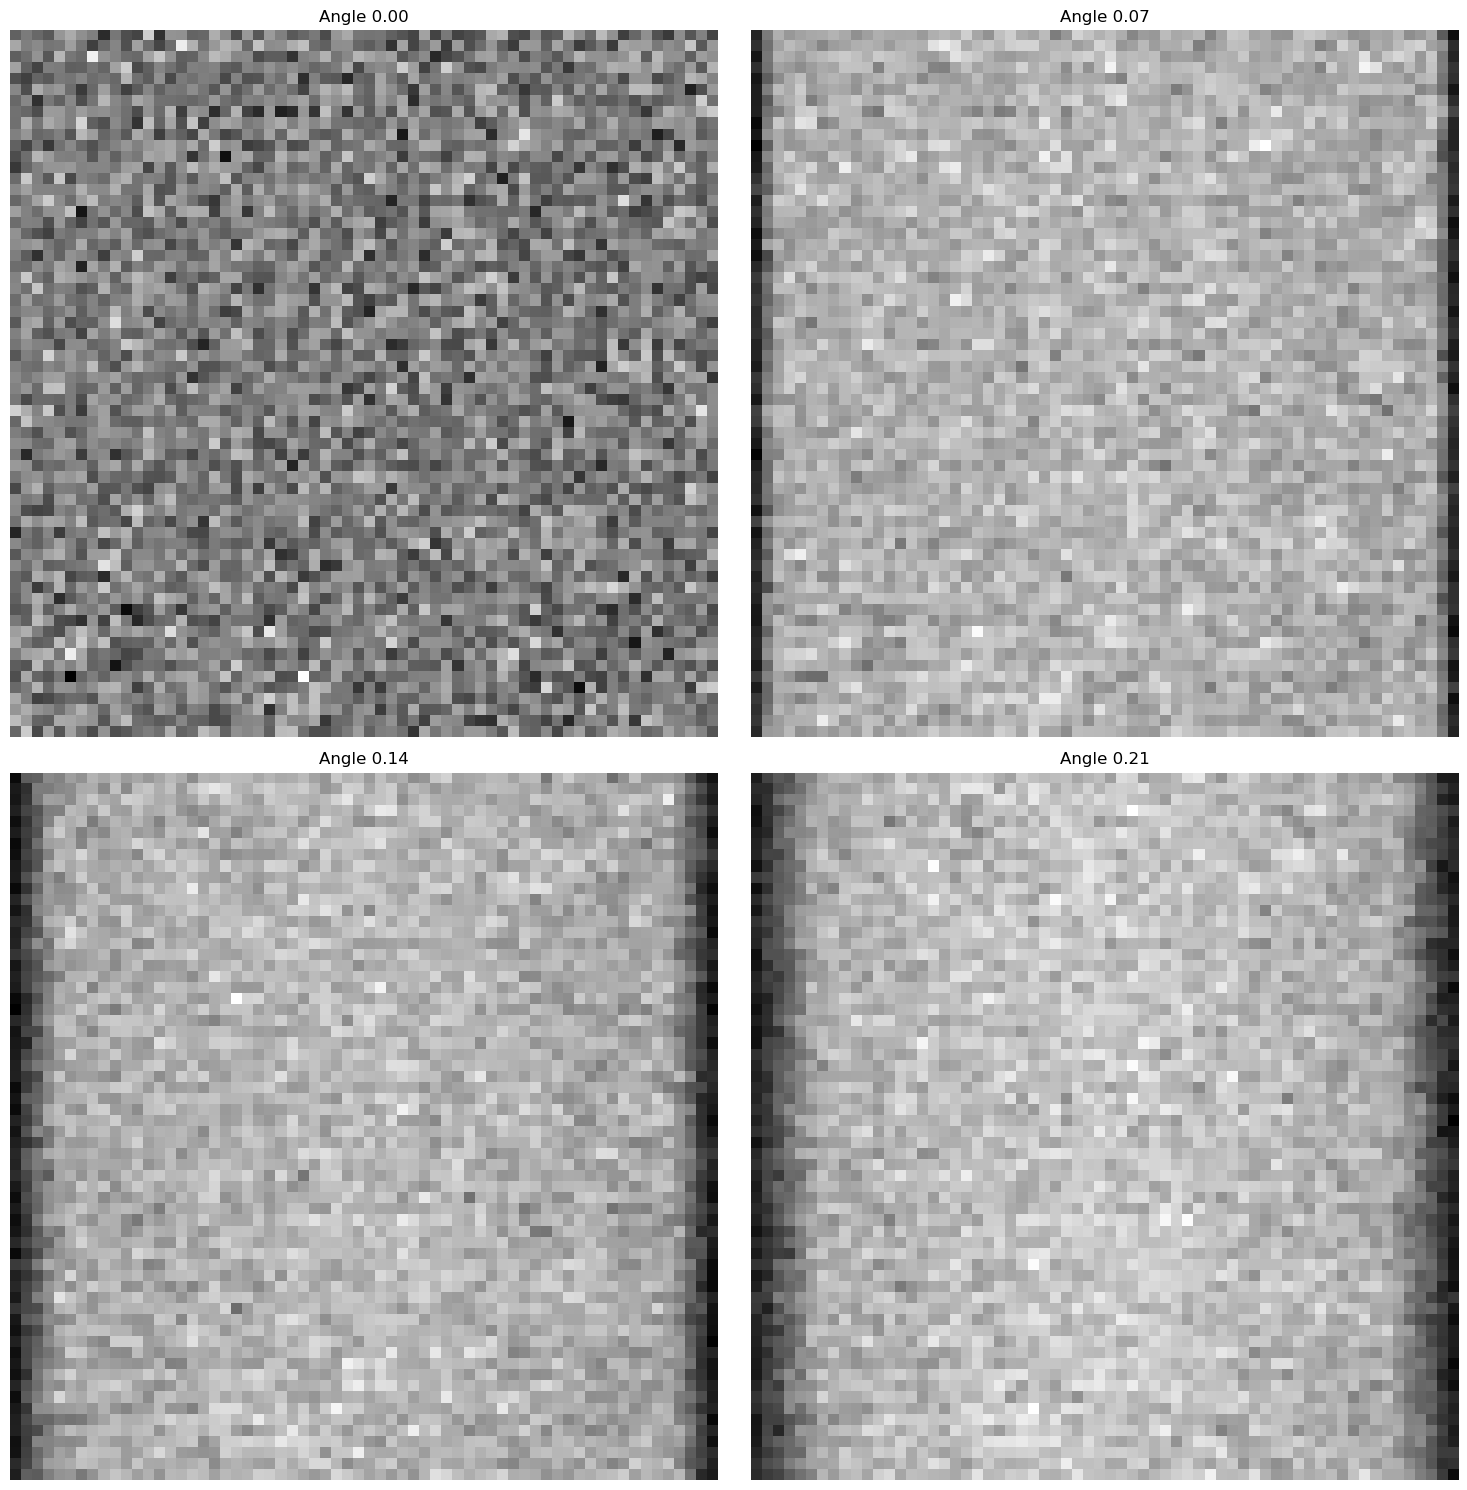

In [14]:
output_untrained = model.apply({"params": params, "state": state})
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
# Loop over the grid and plot the selected slices
for i, ax in enumerate(axs.flat):
    # Display the image
    ax.imshow(output_untrained[i], cmap='gray')
    ax.set_title(f'Angle {angles[i]:.2f}')
    ax.axis('off')  # Turn off axis for cleaner look

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

As expected, there's no meaningful information in the simulated recordings. To start training, and optimizing the sample absorption, we need to define a loss function:

In [15]:
# def loss_fn(params, target):
#     eps = 1e-6
#     approx = model.apply({"params": params})
#     correlation = jnp.corrcoef(approx.flatten().astype(jnp.float32), target.flatten().astype(jnp.float32))[0, 1]
#     loss = 1.0 - correlation# + eps * TV(params['_sample'])
#     return loss, {"loss": loss, "correlation": correlation}

def loss_fn(params, target):
    eps = 1e-5
    approx = model.apply({"params": params})
    loss = optax.cosine_distance(approx.flatten().astype(jnp.float32), target.flatten().astype(jnp.float32))# + eps * TV(params['_sample'])
    return loss, {"loss": loss}

def TV(sample):
  dz = jnp.sum(jnp.abs(sample[0:-1] - sample[1:]))
  dx = jnp.sum(jnp.abs(sample[:,0:-1,:] - sample[:,1:,:]))
  dy = jnp.sum(jnp.abs(sample[:,:,0:-1] - sample[:,:,1:]))
  return dz + dx + dy

By applying `jax.grad` we get the gradient function for the loss function we defined. We also apply `jax.jit` to compile this function:

In [16]:
grad_fn = jax.jit(jax.grad(loss_fn, has_aux=True))

We use the adam optimizer and define a `TrainState`:

In [21]:
model = DifferentiableTomography(forward_model = forward_model,
                                shape = sample.shape,
                                angles=angles)

variables = model.init(key)

params = variables["params"]
state = {}
del variables # delete for memory

In [22]:
optimizer = adam(learning_rate=1e-5)
trainstate = TrainState.create(
    apply_fn=model.apply, 
    params=params, 
    tx=optimizer
)


That's it! We have everything to start the optimization process. In a loop, we will call the `grad_fn` and display the loss value:

In [23]:
max_iterations = 100
history = {"loss": np.zeros((max_iterations)), "correlation": np.zeros((max_iterations))}
for iteration in range(max_iterations):
    grads, metrics = grad_fn(trainstate.params, sinogram)
    trainstate = trainstate.apply_gradients(grads=grads)
    for m in metrics:
        history[m][iteration] = metrics[m]
    #if iteration % 2 == 0:
    print(iteration, metrics)

0 {'loss': Array(0.581854, dtype=float32)}
1 {'loss': Array(nan, dtype=float32)}
2 {'loss': Array(nan, dtype=float32)}
3 {'loss': Array(nan, dtype=float32)}
4 {'loss': Array(nan, dtype=float32)}
5 {'loss': Array(nan, dtype=float32)}
6 {'loss': Array(nan, dtype=float32)}
7 {'loss': Array(nan, dtype=float32)}
8 {'loss': Array(nan, dtype=float32)}
9 {'loss': Array(nan, dtype=float32)}
10 {'loss': Array(nan, dtype=float32)}
11 {'loss': Array(nan, dtype=float32)}
12 {'loss': Array(nan, dtype=float32)}
13 {'loss': Array(nan, dtype=float32)}
14 {'loss': Array(nan, dtype=float32)}
15 {'loss': Array(nan, dtype=float32)}
16 {'loss': Array(nan, dtype=float32)}
17 {'loss': Array(nan, dtype=float32)}
18 {'loss': Array(nan, dtype=float32)}
19 {'loss': Array(nan, dtype=float32)}
20 {'loss': Array(nan, dtype=float32)}
21 {'loss': Array(nan, dtype=float32)}
22 {'loss': Array(nan, dtype=float32)}
23 {'loss': Array(nan, dtype=float32)}
24 {'loss': Array(nan, dtype=float32)}
25 {'loss': Array(nan, dtype=f

ValueError: setting an array element with a sequence.

In [ ]:
fig, ax1 = plt.subplots(dpi=150)

ax1.plot(np.array(history["loss"]), color="black")
ax1.set_ylabel("loss")
ax1.set_xlabel("iterations")

ax2 = ax1.twinx()
ax2.plot(np.array(history["correlation"]), color="red")
ax2.set_ylabel("pearson correlation", color="red")
plt.title("optimization progress")
plt.show()

In [ ]:
learned = model.apply({"params": trainstate.params, "state": state}).intensity.squeeze()